# HiFi Phase 16 - Live 4-Arm Paper-Trading Report

**Status: EXPERIMENT IN PROGRESS - not for performance conclusions yet.**
Paper trading only. Not investment advice. Arms have different inception dates.

Four strategies, same 98-ticker universe, $100K each, one decision/day:

| Arm | Strategy | Type |
|---|---|---|
| **A** | parallel ensemble (champion) | LLM |
| **B** | full sequential (herding contrast) | LLM |
| **C** | equal-weight buy-and-hold | null control |
| **D** | riskbudget calm_exposure | deterministic quant |

Auto-generated from captured data (`data/live/{arm}/`): no hand-picking.
Regenerate any time - it enriches as data accumulates. Financial metrics stay
blank until >=20 daily returns exist (early days are noise).

In [1]:
import sys
from pathlib import Path
# Resolve repo root whether run from repo root or notebooks/
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
DATA = str(ROOT / "data")

import pandas as pd, matplotlib.pyplot as plt
from hifi.analytics import live_report as lr
pd.set_option("display.width", 160); plt.rcParams["figure.figsize"] = (11, 5)
status = lr.experiment_status(DATA)
print("Repo:", ROOT)
print("Days of data:", status["days_of_data"], "| window:", status["first_date"], "->", status["last_date"])
print("Arms live:", status["arms_live"])
print("Live IC:", status["ic_status"])

Repo: /Users/alberto/Documents/projects/HiFi
Days of data: 6 | window: 2026-07-11 -> 2026-07-18
Arms live: ['A', 'B', 'C', 'D']
Live IC: pending — needs 60-day forward labels (Phase 16 E3)


## 1 - Financial layer: equity curves + metrics
Alpaca's authoritative close-marked curve, rebased to 100.

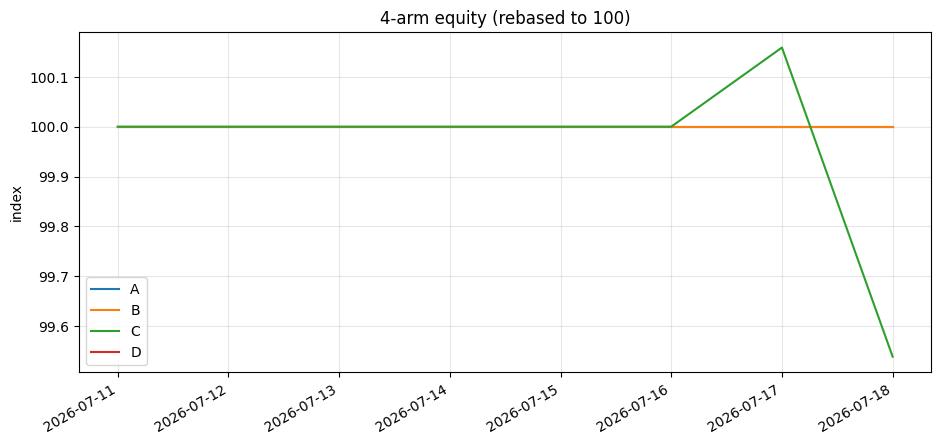

,A,B,C,D
2026-07-14,100.0,100.0,100.00000,NaN
2026-07-15,100.0,100.0,100.00000,NaN
2026-07-16,100.0,100.0,100.00000,NaN
2026-07-17,100.0,100.0,100.15878,NaN
2026-07-18,100.0,100.0,99.53859,100.0


In [2]:
curves = lr.equity_curves(DATA, rebased=True)
if not curves.empty and len(curves) > 1:
    ax = curves.plot(title="4-arm equity (rebased to 100)"); ax.set_ylabel("index"); ax.grid(alpha=.3); plt.show()
else:
    print(f"Only {len(curves)} day(s) - curve appears once >1 day accumulates.")
curves.tail()

In [3]:
m = lr.metrics_table(DATA)
disp = m[["strategy","days","return_days","current_equity","total_return_pct",
          "cagr_pct","sharpe","sortino","max_drawdown_pct","volatility_pct","enough_data"]]
print("History-dependent metrics (Sharpe etc.) populate once return_days >= 20.")
disp

History-dependent metrics (Sharpe etc.) populate once return_days >= 20.


,strategy,days,return_days,current_equity,total_return_pct,cagr_pct,sharpe,sortino,max_drawdown_pct,volatility_pct,enough_data
arm,,,,,,,,,,,
A,parallel ensemble (champion),6,5,100000.00,0.00000,None,None,None,None,None,False
B,full sequential (herding contrast),6,5,100000.00,0.00000,None,None,None,None,None,False
C,equal-weight control (null model),6,5,99538.59,-0.46141,None,None,None,None,None,False
D,riskbudget calm_exposure (quant),1,0,100000.00,NaN,None,None,None,None,None,False


## 2 - Per-arm QuantStats tearsheet
Full tearsheet per arm once enough history exists; QuantStats is the standard financial layer.

In [4]:
import quantstats as qs
MIN = 20
for arm in lr.ARMS:
    r = lr.load_returns(arm, DATA)
    if len(r) >= MIN:
        print(f"=== Arm {arm}: {lr.ARMS[arm]['label']} ===")
        qs.reports.metrics(r, mode="basic", display=True)
    else:
        print(f"Arm {arm}: {len(r)} return days (<{MIN}) - tearsheet pending.")

Arm A: 5 return days (<20) - tearsheet pending.
Arm B: 5 return days (<20) - tearsheet pending.
Arm C: 5 return days (<20) - tearsheet pending.
Arm D: 0 return days (<20) - tearsheet pending.


## 3 - Decision-science layer
The novel contribution: how the strategies *decide*, not just what they return.

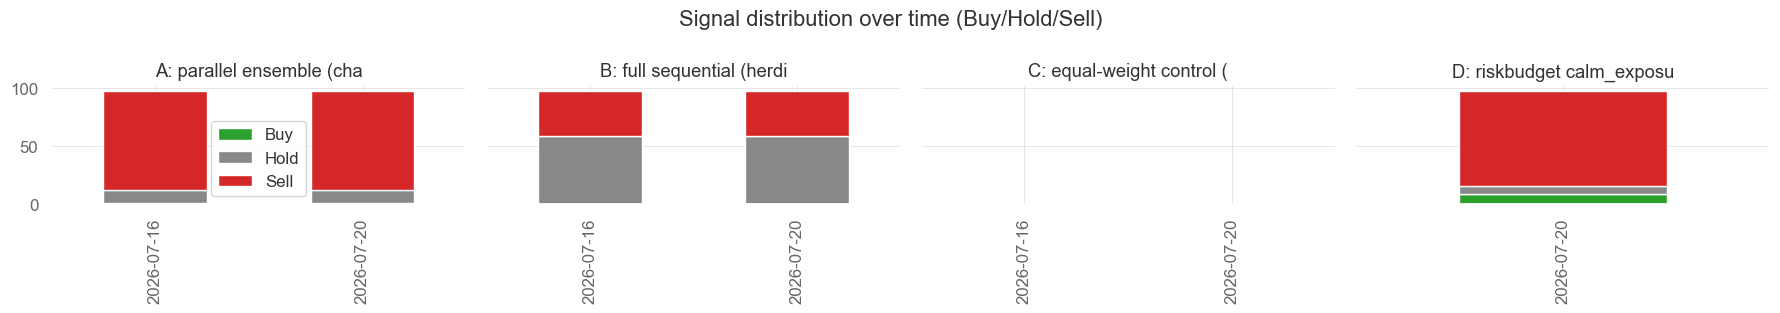

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.2), sharey=True)
for ax, arm in zip(axes, lr.ARMS):
    sd = lr.signal_distribution(arm, DATA)
    if not sd.empty:
        sd = sd.set_index("decision_date")[["Buy","Hold","Sell"]]
        sd.plot(kind="bar", stacked=True, ax=ax, legend=(arm=="A"),
                color={"Buy":"#2ca02c","Hold":"#888888","Sell":"#d62728"})
    ax.set_title(f"{arm}: {lr.ARMS[arm]['label'][:22]}"); ax.set_xlabel("")
plt.suptitle("Signal distribution over time (Buy/Hold/Sell)"); plt.tight_layout(); plt.show()

### 3b - Herding vs diversity (LLM arms)
Page's theorem, live: **unanimity** = fraction of tickers where all agents agreed
(high = herding); **mean_entropy** = cross-agent disagreement (high = diverse).
Phase 15 found parallel (A) diverse / low-herding, full (B) higher-herding.

In [6]:
for arm in ["A","B"]:
    h = lr.herding_series(arm, DATA)
    if h.empty:
        print(f"Arm {arm}: no ensemble sidecars yet."); continue
    print(f"=== Arm {arm} ({lr.ARMS[arm]['label']}) ===")
    print(h.to_string(index=False))

=== Arm A (parallel ensemble (champion)) ===
decision_date  n_tickers  unanimity  mean_entropy
   2026-07-16         98        0.0      0.936457
   2026-07-20         98        0.0      0.925292
=== Arm B (full sequential (herding contrast)) ===
decision_date  n_tickers  unanimity  mean_entropy
   2026-07-16         98   0.153061      0.759509


### 3c - Live Information Coefficient (pending)
IC (rank corr of signal vs 60-day forward return) requires forward-return
labels, built in Phase 16 E3 once >=60 trading days have elapsed. This panel
will populate then. Placeholder kept so the report structure is stable.

In [7]:
print("Live IC:", lr.experiment_status(DATA)["ic_status"])

Live IC: pending — needs 60-day forward labels (Phase 16 E3)
